# Family-Vicsek: height scaling

Notebook para analisar as series de altura/rugosidade salvas em `.yts` e processadas para `.csv.gz`.

Fluxo esperado antes de abrir este notebook:

```bash
cd /home/light/Documents/self_organization_percolation/tools
./process_height_timeseries.py --root ../SOP_data/raw_growth_test_dynamic --out-root ../SOP_data/processed_height_timeseries
./process_height_ensemble_series.py --root ../SOP_data/raw_growth_test_dynamic --out-root ../SOP_data/processed_height_timeseries
```

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path('src').resolve()))

from src.family_vicsek_height import (
    available_parameter_sets,
    filter_params,
    load_ensemble_series,
    load_sample_summary,
    plot_alpha_estimate,
    plot_w_mean_with_beta,
    plot_z_estimate,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## Carregar dados processados

In [3]:
processed_root = Path('../SOP_data/processed_height_timeseries')

ensemble_path = processed_root / 'height_ensemble_timeseries_all.csv.gz'
summary_path = processed_root / 'height_group_summary.csv.gz'

ensemble = load_ensemble_series(ensemble_path)
summary = load_sample_summary(summary_path)

ensemble.shape, summary.shape

((23716490, 24), (506, 22))

In [4]:
available_parameter_sets(ensemble)

,type_perc,f_T,c,rho,color
0,bond,0.010000,0.01,1,0
1,bond,0.010000,0.05,1,0
2,bond,0.020000,0.01,1,0
3,bond,0.025263,0.01,1,0
4,bond,0.025263,0.05,1,0
...,...,...,...,...,...
123,node,0.280000,0.05,1,0
124,node,0.290000,0.01,1,0
125,node,0.290000,0.05,1,0
126,node,0.300000,0.01,1,0


## Escolher parametros

In [5]:
# Altere estes valores para o grupo que quiser analisar.
type_perc = 'bond'
f_T = 0.3
c = 0.01
rho = 1.0
color = 0

Ls = sorted(filter_params(ensemble, type_perc=type_perc, f_T=f_T, c=c, rho=rho, color=color)['L'].unique())
Ls

[512, 1024, 2048, 4096, 8192, 16384]

## Plot de W(t) medio e expoente local

{'beta': 1.3444366263979248,
 'intercept': -4.279756235458955,
 'r2': 0.999976510049351,
 'n': 160,
 't_min': 76.49836599562111,
 't_max': 236.49383348769783,
 'beta_eff_mean': 1.3413760039268976,
 'beta_eff_std': 0.02143952966602242,
 'score': 0.9984596968546742}

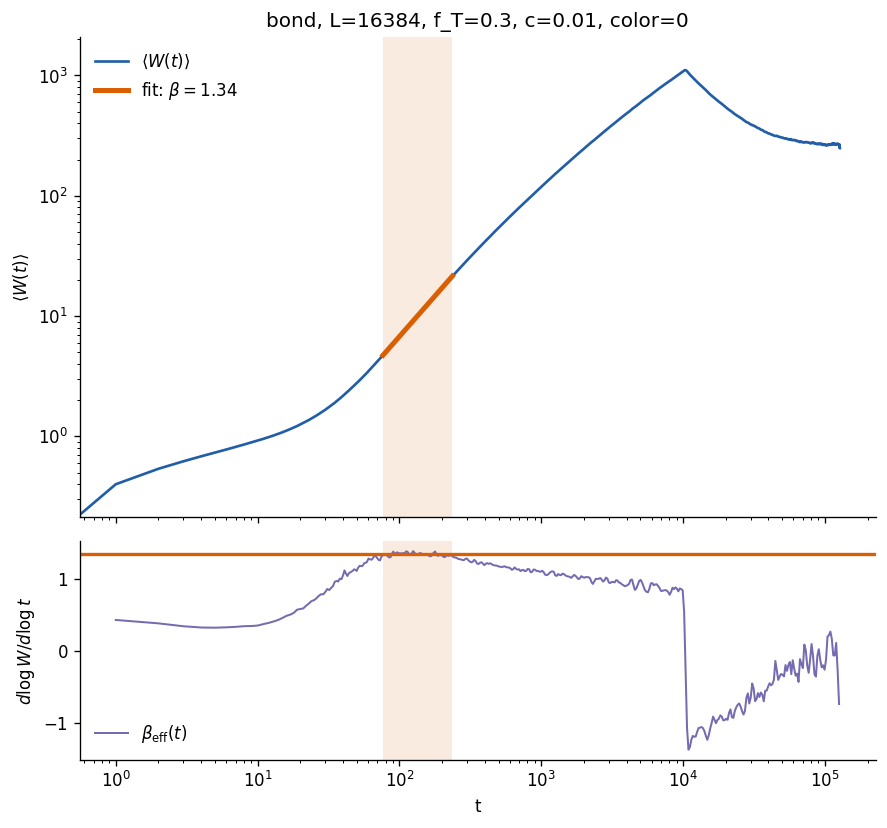

In [ ]:
# Escolha um L especifico. Se existir, o maior L costuma ser o mais informativo.
L = max(Ls)

fig, axes, beta_fit = plot_w_mean_with_beta(
    ensemble,
    type_perc=type_perc,
    f_T=f_T,
    c=c,
    rho=rho,
    color=color,
    L=L,
    min_count=5,
    min_n_frac=0.8,
    fit_kwargs={
        
        'max_beta_std': 0.20,
        'min_decades': 0.35,
        'min_points': 24,
    },
)

beta_fit

## Comparar W(t) para todos os L do mesmo grupo

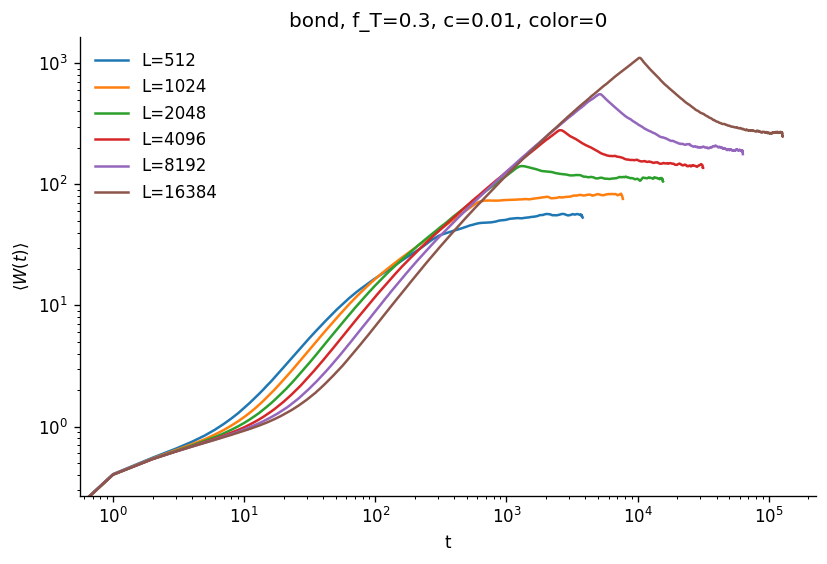

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

for L_value in Ls:
    data = filter_params(ensemble, type_perc=type_perc, f_T=f_T, c=c, rho=rho, color=color, L=L_value)
    data = data.sort_values('t')
    max_n = data['n'].max()
    data = data[data['n'] >= max(5, int(np.ceil(0.8 * max_n)))]
    ax.plot(data['t'], data['y_width_mean'], lw=1.5, label=f'L={L_value}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('t')
ax.set_ylabel(r'$\langle W(t)\rangle$')
ax.legend(frameon=False)
ax.set_title(f'{type_perc}, f_T={f_T:.8g}, c={c:g}, color={color}')
fig.tight_layout()

## Estimar alpha por W_sat(L) ~ L^alpha

{'slope': 0.43751152436143115,
 'intercept': 1.3373479785121118,
 'r2': 0.9961114488867309,
 'n': 6}

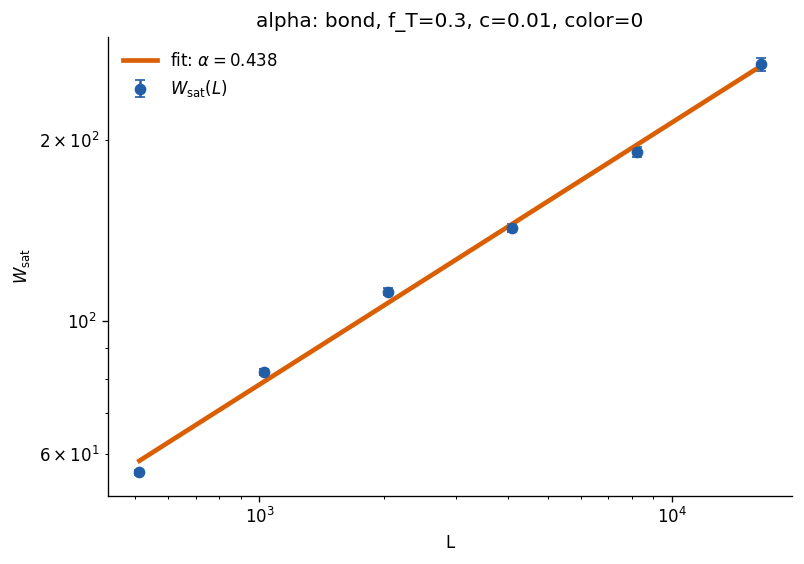

In [8]:
fig, ax, alpha_fit = plot_alpha_estimate(
    summary,
    type_perc=type_perc,
    f_T=f_T,
    c=c,
    rho=rho,
    color=color,
)

alpha_fit

## Estimar z por t_x(L) ~ L^z

{'slope': 0.22807508869034723,
 'intercept': 5.220798976778113,
 'r2': 0.7764953973304912,
 'n': 6}

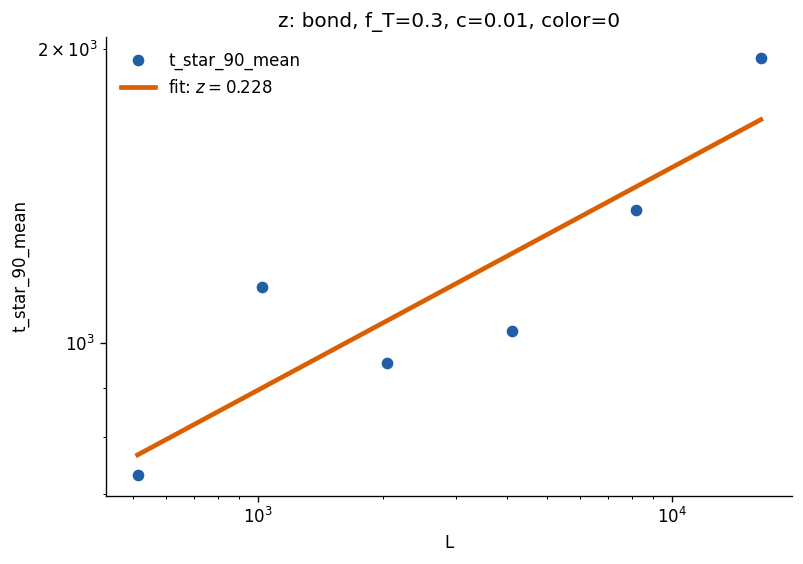

In [9]:
# t_star_90_mean costuma ser uma aproximacao melhor do crossover para saturacao.
fig, ax, z_fit = plot_z_estimate(
    summary,
    type_perc=type_perc,
    f_T=f_T,
    c=c,
    rho=rho,
    color=color,
    t_column='t_star_90_mean',
)

z_fit

## Checagem Family-Vicsek

In [10]:
beta = beta_fit['beta']
alpha = alpha_fit['slope']
z = z_fit['slope']

pd.DataFrame([
    {
        'type_perc': type_perc,
        'f_T': f_T,
        'c': c,
        'rho': rho,
        'color': color,
        'beta': beta,
        'alpha': alpha,
        'z': z,
        'alpha_over_z': alpha / z,
        'beta_minus_alpha_over_z': beta - alpha / z,
    }
])

,type_perc,f_T,c,rho,color,beta,alpha,z,alpha_over_z,beta_minus_alpha_over_z
0,bond,0.3,0.01,1.0,0,1.344437,0.437512,0.228075,1.918278,-0.573842
